## Imports & config

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shutil

from scipy.stats import chi2_contingency, f_oneway
from scipy.optimize import nnls
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTENC
from xgboost import XGBClassifier

import keras_tuner as kt
from tensorflow import keras
from tensorflow.keras import layers

pd.set_option("display.max_columns", None)

CSV_PATH = "hmda_ready_decisions.csv"
TARGET = "approved"
RANDOM_STATE = 42

NUMERIC_COLS = [
    "interest_rate", "loan_to_value_ratio", "property_value",
    "income_000s", "loan_term_months",
]
CATEGORICAL_FILL = ["county_code", "dti_ratio", "denial_reason_label"]
FAKE_LIMITS = {
    "loan_to_value_ratio": 150,     # LTV above ~150% is not real
    "property_value": 5_000_000,    # a home over $5M here is junk
}

## Load

In [2]:
df = pd.read_csv(CSV_PATH, low_memory=False)
print(df.shape)
df.head()

(1037862, 29)


,year,lender_id,state,county_code,metro_area_code,loan_outcome,loan_type,loan_purpose,loan_amount,loan_term_months,interest_rate,loan_to_value_ratio,property_value,income_000s,dti_ratio,race,ethnicity,sex,applicant_age,occupancy_type,denial_reason_1,tract_minority_population_pct,area_median_family_income,loan_outcome_label,loan_type_label,loan_purpose_label,occupancy_label,denial_reason_label,approved
0,2025,549300HW662MN1WU8550,CO,8041.0,17820,1,3,31,465000,360,6.125,98.724,475000.0,NaN,NaN,Race Not Available,Ethnicity Not Available,Sex Not Available,55-64,1,10,39.55,113400,Approved,VA,Refinance,Principal residence,Not applicable,1
1,2025,549300HW662MN1WU8550,MT,30063.0,33540,1,1,1,315000,360,6.125,80.000,395000.0,61.0,48,White,Not Hispanic or Latino,Male,25-34,1,10,17.93,105800,Approved,Conventional,Home purchase,Principal residence,Not applicable,1
2,2025,549300HW662MN1WU8550,SC,45083.0,43900,1,3,31,515000,360,5.625,99.612,515000.0,NaN,NaN,Black or African American,Not Hispanic or Latino,Joint,55-64,1,10,27.82,80900,Approved,VA,Refinance,Principal residence,Not applicable,1
3,2025,549300HW662MN1WU8550,PA,42043.0,25420,1,1,1,565000,360,7.375,80.000,715000.0,206.0,45,Asian,Not Hispanic or Latino,Joint,55-64,1,10,7.00,105400,Approved,Conventional,Home purchase,Principal residence,Not applicable,1
4,2025,549300HW662MN1WU8550,CO,8069.0,22660,1,1,1,755000,360,6.490,95.000,795000.0,190.0,47,White,Not Hispanic or Latino,Joint,25-34,1,10,15.95,127600,Approved,Conventional,Home purchase,Principal residence,Not applicable,1


## Clean numeric columns

In [3]:
def clean_numeric(frame, numeric_cols, fake_limits):
    """Coerce to numeric and null out impossible values. Returns a new frame."""
    frame = frame.copy()
    frame[numeric_cols] = frame[numeric_cols].apply(pd.to_numeric, errors="coerce")
    for col, limit in fake_limits.items():
        n_fake = (frame[col] > limit).sum()
        print(f"{col}: {n_fake:,} impossible values (> {limit:,}) set to NaN")
        frame.loc[frame[col] > limit, col] = np.nan
    return frame

df = clean_numeric(df, NUMERIC_COLS, FAKE_LIMITS)

loan_to_value_ratio: 959 impossible values (> 150) set to NaN
property_value: 2,653 impossible values (> 5,000,000) set to NaN


## Impute missing values

In [4]:
df[NUMERIC_COLS] = df[NUMERIC_COLS].fillna(df[NUMERIC_COLS].median())
df[CATEGORICAL_FILL] = df[CATEGORICAL_FILL].fillna(df[CATEGORICAL_FILL].mode().iloc[0])

assert df.isna().sum().sum() == 0, "still have missing values"
print("0 missing values left")

0 missing values left


## EDA

Missing % by column:
year                             0.0
lender_id                        0.0
state                            0.0
county_code                      0.0
metro_area_code                  0.0
loan_outcome                     0.0
loan_type                        0.0
loan_purpose                     0.0
loan_amount                      0.0
loan_term_months                 0.0
interest_rate                    0.0
loan_to_value_ratio              0.0
property_value                   0.0
income_000s                      0.0
dti_ratio                        0.0
race                             0.0
ethnicity                        0.0
sex                              0.0
applicant_age                    0.0
occupancy_type                   0.0
denial_reason_1                  0.0
tract_minority_population_pct    0.0
area_median_family_income        0.0
loan_outcome_label               0.0
loan_type_label                  0.0
loan_purpose_label               0.0
occupancy_label  

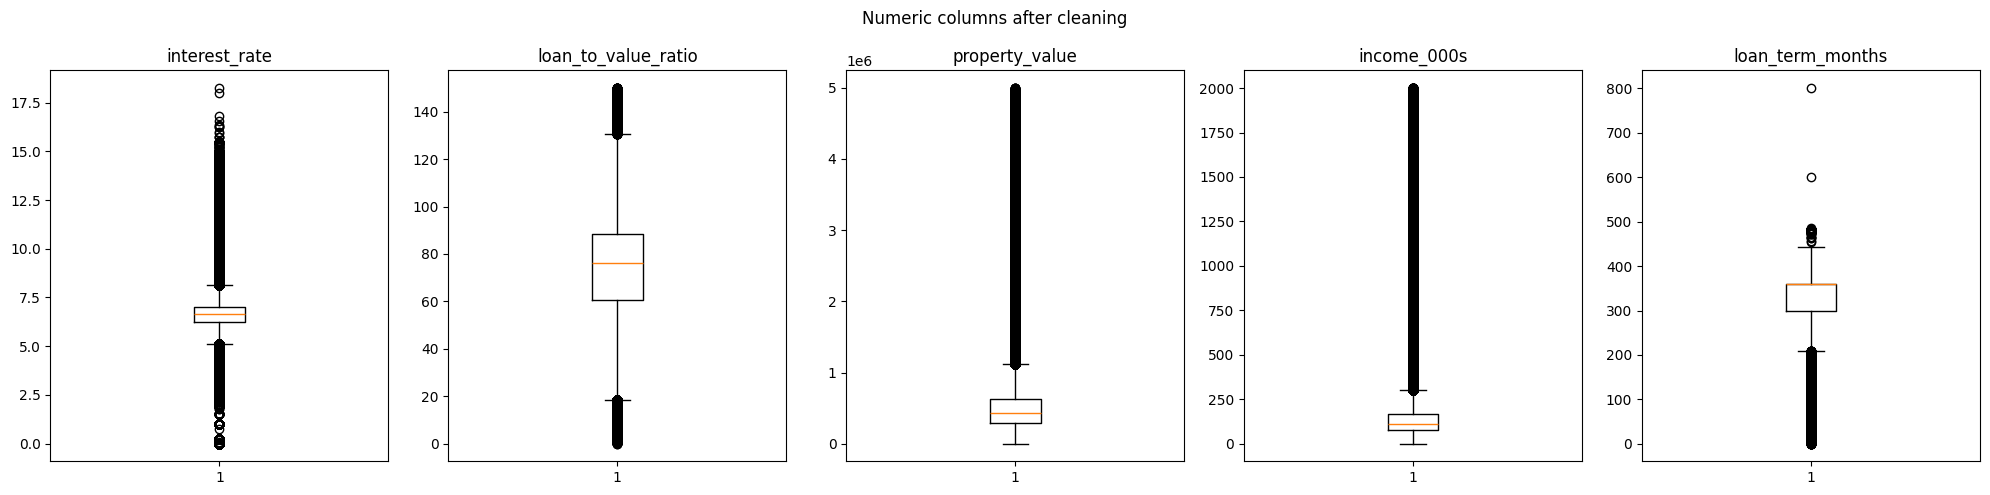


Target balance:
approved
1    78.1
0    21.9
Name: count, dtype: float64


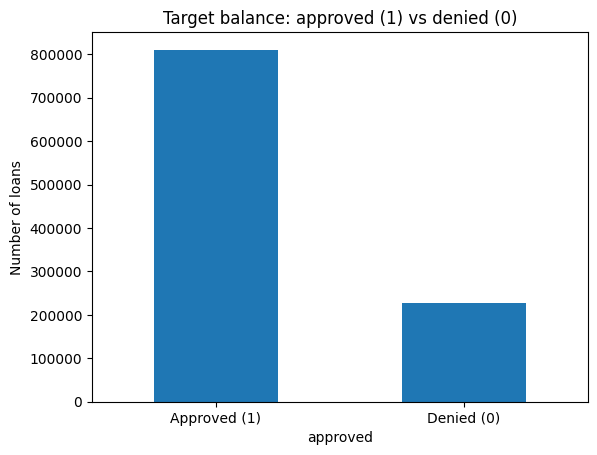

In [5]:
def boxplot_grid(frame, cols, title=None):
    """One box plot per column, side by side."""
    fig, axes = plt.subplots(1, len(cols), figsize=(4 * len(cols), 5))
    for ax, col in zip(np.atleast_1d(axes), cols):
        ax.boxplot(pd.to_numeric(frame[col], errors="coerce").dropna())
        ax.set_title(col)
    if title:
        fig.suptitle(title)
    plt.tight_layout()
    plt.show()

print("Missing % by column:")
print((df.isna().mean() * 100).round(3))

boxplot_grid(df, NUMERIC_COLS, title="Numeric columns after cleaning")

counts = df[TARGET].value_counts()
print("\nTarget balance:")
print((counts / len(df) * 100).round(1))
counts.plot(kind="bar", title="Target balance: approved (1) vs denied (0)")
plt.xticks([0, 1], ["Approved (1)", "Denied (0)"], rotation=0)
plt.ylabel("Number of loans")
plt.show()

## Feature significance

In [6]:
CAT_TESTS = [
    "state", "loan_type_label", "loan_purpose_label", "occupancy_label",
    "race", "ethnicity", "sex", "applicant_age", "dti_ratio",
]
NUM_TESTS = [
    "income_000s", "property_value", "loan_to_value_ratio", "loan_term_months",
    "tract_minority_population_pct", "area_median_family_income",
    "loan_amount", "interest_rate",
]

def chi_square_scores(frame, cols, target):
    rows = [(col, *chi2_contingency(pd.crosstab(frame[col], frame[target]))[:2])
            for col in cols]
    out = pd.DataFrame(rows, columns=["feature", "chi2", "p"])
    return out.sort_values("chi2", ascending=False)

def anova_scores(frame, cols, target):
    rows = []
    for col in cols:
        groups = [g[col].values for _, g in frame.groupby(target)]
        F, p = f_oneway(*groups)
        rows.append((col, F, p))
    return pd.DataFrame(rows, columns=["feature", "F", "p"]).sort_values("F", ascending=False)

def vif_scores(frame, cols):
    X = frame[cols].to_numpy()
    X = (X - X.mean(0)) / X.std(0)          # standardize
    vifs = [variance_inflation_factor(X, i) for i in range(len(cols))]
    return pd.DataFrame({"feature": cols, "VIF": vifs}).sort_values("VIF", ascending=False)

chi = chi_square_scores(df, CAT_TESTS, TARGET)
chi["significant"] = chi["p"] < 0.05
print("CHI-SQUARE (categorical vs approved)\n", chi.to_string(index=False), "\n")

anova = anova_scores(df, NUM_TESTS, TARGET)
anova["significant"] = anova["p"] < 0.05
print("ANOVA F-TEST (numeric vs approved)\n", anova.to_string(index=False), "\n")

print("VIF (multicollinearity; > 5 is a concern)\n",
      vif_scores(df, NUM_TESTS).to_string(index=False))

CHI-SQUARE (categorical vs approved)
            feature          chi2            p  significant
         dti_ratio 218785.560197 0.000000e+00         True
loan_purpose_label  64829.525743 0.000000e+00         True
              race  15371.697311 0.000000e+00         True
               sex  13371.206034 0.000000e+00         True
     applicant_age   8950.744240 0.000000e+00         True
         ethnicity   4574.263965 0.000000e+00         True
             state   2358.298728 0.000000e+00         True
   loan_type_label   1844.688672 0.000000e+00         True
   occupancy_label     42.292951 6.549414e-10         True 

ANOVA F-TEST (numeric vs approved)
                       feature            F             p  significant
                  income_000s 15312.275791  0.000000e+00         True
               property_value  6316.747453  0.000000e+00         True
          loan_to_value_ratio  4062.189129  0.000000e+00         True
             loan_term_months  3800.801966  0.000000e+

## Drop leakage & useless columns

In [7]:
drop_cols = [
    "lender_id",                                 # 2,083 unique IDs -> no signal
    "year",                                      # constant (all 2025)
    "loan_outcome", "loan_outcome_label",        # the answer itself (leakage)
    "denial_reason_1", "denial_reason_label",    # only exist for denials (leakage)
    "interest_rate",                             # missing for 100% of denials (leakage)
    "loan_type", "loan_purpose", "occupancy_type",  # numeric dupes of *_label cols
    "county_code", "metro_area_code",            # hundreds of categories -> huge SMOTE memory
]
model_df = df.drop(columns=drop_cols)
print(model_df.shape)

(1037862, 17)


## Encode + split

In [8]:
X = model_df.drop(columns=[TARGET])
y = model_df[TARGET]

cat_cols = ["state", "dti_ratio", "race", "sex", "ethnicity", "applicant_age",
            "loan_type_label", "loan_purpose_label", "occupancy_label"]
for c in cat_cols:
    X[c] = LabelEncoder().fit_transform(X[c].astype(str))

X_tv, X_test, y_tv, y_test = train_test_split(
    X, y, test_size=0.10, stratify=y, random_state=RANDOM_STATE)
X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv, test_size=0.20 / 0.90, stratify=y_tv, random_state=RANDOM_STATE)

for name, part in {"TRAIN": y_train, "VAL": y_val, "TEST": y_test}.items():
    ap = part.mean() * 100
    print(f"{name:<6} {len(part):>9,} rows   approved: {ap:.1f}% / denied: {100 - ap:.1f}%")

TRAIN    726,502 rows   approved: 78.1% / denied: 21.9%
VAL      207,573 rows   approved: 78.1% / denied: 21.9%
TEST     103,787 rows   approved: 78.1% / denied: 21.9%


## SMOTE-NC

In [9]:
cat_idx = [X.columns.get_loc(c) for c in cat_cols]
smote = SMOTENC(categorical_features=cat_idx, random_state=RANDOM_STATE)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("TRAIN before SMOTE:", dict(y_train.value_counts()))
print("TRAIN after  SMOTE:", dict(y_train_res.value_counts()))
print(f"Rows: {len(X_train):,} -> {len(X_train_res):,}")

TRAIN before SMOTE: {1: 567286, 0: 159216}
TRAIN after  SMOTE: {1: 567286, 0: 567286}
Rows: 726,502 -> 1,134,572


## Evaluate helper

In [10]:
def evaluate(name, y_true, y_pred):
    print(f"\n===== {name} =====")
    print(classification_report(y_true, y_pred,
                                target_names=["Denied (0)", "Approved (1)"], digits=3))
    print("Confusion matrix [rows=actual, cols=pred]:")
    print(confusion_matrix(y_true, y_pred))
    print(f"macro-F1: {f1_score(y_true, y_pred, average='macro'):.3f} | "
          f"F1 (denied): {f1_score(y_true, y_pred, pos_label=0):.3f}")

## Logistic Regression

In [11]:
num_cols = [c for c in X.columns if c not in cat_cols]
pre = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ("num", StandardScaler(), num_cols),
])

logreg = Pipeline([("prep", pre), ("clf", LogisticRegression(max_iter=1000))])
logreg.fit(X_train_res, y_train_res)
evaluate("Logistic Regression", y_val, logreg.predict(X_val))


===== Logistic Regression =====
              precision    recall  f1-score   support

  Denied (0)      0.481     0.587     0.529     45491
Approved (1)      0.877     0.822     0.848    162082

    accuracy                          0.771    207573
   macro avg      0.679     0.705     0.689    207573
weighted avg      0.790     0.771     0.778    207573

Confusion matrix [rows=actual, cols=pred]:
[[ 26721  18770]
 [ 28821 133261]]
macro-F1: 0.689 | F1 (denied): 0.529


 ## Random Forest

In [12]:
rf = RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=RANDOM_STATE)
rf.fit(X_train_res, y_train_res)
evaluate("Random Forest", y_val, rf.predict(X_val))


===== Random Forest =====
              precision    recall  f1-score   support

  Denied (0)      0.704     0.624     0.661     45491
Approved (1)      0.898     0.926     0.912    162082

    accuracy                          0.860    207573
   macro avg      0.801     0.775     0.787    207573
weighted avg      0.855     0.860     0.857    207573

Confusion matrix [rows=actual, cols=pred]:
[[ 28385  17106]
 [ 11963 150119]]
macro-F1: 0.787 | F1 (denied): 0.661


## XGBoost

In [13]:
xgb = XGBClassifier(
    n_estimators=400, max_depth=6, learning_rate=0.1,
    subsample=0.9, colsample_bytree=0.9,
    eval_metric="logloss", n_jobs=-1, random_state=RANDOM_STATE,
)
xgb.fit(X_train_res, y_train_res)
evaluate("XGBoost", y_val, xgb.predict(X_val))


===== XGBoost =====
              precision    recall  f1-score   support

  Denied (0)      0.708     0.602     0.651     45491
Approved (1)      0.893     0.930     0.911    162082

    accuracy                          0.858    207573
   macro avg      0.800     0.766     0.781    207573
weighted avg      0.852     0.858     0.854    207573

Confusion matrix [rows=actual, cols=pred]:
[[ 27402  18089]
 [ 11302 150780]]
macro-F1: 0.781 | F1 (denied): 0.651


## Keras preprocessing

In [14]:
pre_nn = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
    ("num", StandardScaler(), num_cols),
])
X_train_nn = pre_nn.fit_transform(X_train_res)   # balanced training data
X_val_nn = pre_nn.transform(X_val)               # untouched validation
n_features = X_train_nn.shape[1]
print("Input features after one-hot:", n_features)

Input features after one-hot: 74


## Keras tuner search

In [15]:
shutil.rmtree("kt_dir", ignore_errors=True)   # clear any stale trials from old runs

def build_model(hp):
    model = keras.Sequential([keras.Input(shape=(n_features,))])
    for i in range(hp.Int("n_layers", 1, 3)):          # 1-3 hidden layers
        model.add(layers.Dense(hp.Int(f"units_{i}", 32, 256, step=32), activation="relu"))
        model.add(layers.Dropout(hp.Float(f"dropout_{i}", 0.0, 0.5, step=0.1)))
    model.add(layers.Dense(1, activation="sigmoid"))    # yes/no output
    model.compile(
        optimizer=keras.optimizers.Adam(hp.Choice("lr", [1e-2, 1e-3, 1e-4])),
        loss="binary_crossentropy",
        metrics=[keras.metrics.AUC(name="auc"), "accuracy"],
    )
    return model

tuner = kt.RandomSearch(build_model, objective=kt.Objective("val_auc", "max"),
                        max_trials=10, overwrite=True,          # start fresh
                        directory="kt_dir", project_name="hmda_nn")

early = keras.callbacks.EarlyStopping(monitor="val_loss", patience=3,
                                      restore_best_weights=True)
tuner.search(X_train_nn, y_train_res,
             validation_data=(X_val_nn, y_val),
             epochs=10, batch_size=1024, callbacks=[early], verbose=1)

# Rebuild the best model from its hyperparameters and retrain it, instead of
# tuner.get_best_models() which reloads weights from disk and can hit the
# 74-vs-75 shape mismatch. This trains the winning config from scratch.
best_hp = tuner.get_best_hyperparameters(1)[0]
print("Best hyperparameters:", best_hp.values)

best_model = build_model(best_hp)
best_model.fit(X_train_nn, y_train_res,
               validation_data=(X_val_nn, y_val),
               epochs=20, batch_size=1024, callbacks=[early], verbose=1)

Trial 15 Complete [00h 05m 45s]
val_auc: 0.8446021676063538

Best val_auc So Far: 0.8515082597732544
Total elapsed time: 00h 44m 03s
Best hyperparameters: {'n_layers': 3, 'units_0': 192, 'dropout_0': 0.30000000000000004, 'lr': 0.001, 'units_1': 160, 'dropout_1': 0.2, 'units_2': 192, 'dropout_2': 0.0}
Epoch 1/20
1108/1108 ━━━━━━━━━━━━━━━━━━━━ 26s 22ms/step - accuracy: 0.7714 - auc: 0.8534 - loss: 0.4638 - val_accuracy: 0.8255 - val_auc: 0.8405 - val_loss: 0.4129
Epoch 2/20
1108/1108 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step - accuracy: 0.8155 - auc: 0.8967 - loss: 0.3983 - val_accuracy: 0.8297 - val_auc: 0.8448 - val_loss: 0.4036
Epoch 3/20
1108/1108 ━━━━━━━━━━━━━━━━━━━━ 16s 14ms/step - accuracy: 0.8211 - auc: 0.9016 - loss: 0.3890 - val_accuracy: 0.8308 - val_auc: 0.8476 - val_loss: 0.4042
Epoch 4/20
1108/1108 ━━━━━━━━━━━━━━━━━━━━ 21s 15ms/step - accuracy: 0.8251 - auc: 0.9050 - loss: 0.3824 - val_accuracy: 0.8348 - val_auc: 0.8495 - val_loss: 0.3977
Epoch 5/20
1108/1108 ━━━━━━━━━━━━━━━━━━━━ 

## Keras evaluation

In [16]:
y_pred_nn = (best_model.predict(X_val_nn) > 0.5).astype(int).ravel()
evaluate("Deep Learning (Keras)", y_val, y_pred_nn)

6487/6487 ━━━━━━━━━━━━━━━━━━━━ 10s 1ms/step

===== Deep Learning (Keras) =====
              precision    recall  f1-score   support

  Denied (0)      0.674     0.598     0.634     45491
Approved (1)      0.891     0.919     0.905    162082

    accuracy                          0.849    207573
   macro avg      0.782     0.759     0.769    207573
weighted avg      0.843     0.849     0.845    207573

Confusion matrix [rows=actual, cols=pred]:
[[ 27223  18268]
 [ 13172 148910]]
macro-F1: 0.769 | F1 (denied): 0.634


## Least-squares blend: fit weights on validation

In [17]:
model_names = ["LogReg", "RF", "XGB", "Keras"]
P_val = np.column_stack([
    logreg.predict_proba(X_val)[:, 1],
    rf.predict_proba(X_val)[:, 1],
    xgb.predict_proba(X_val)[:, 1],
    best_model.predict(X_val_nn, verbose=0).ravel(),
])

w, _ = nnls(P_val, y_val.to_numpy(dtype=float))
w = w / w.sum()
print("Blend weights:", {n: round(float(wi), 3) for n, wi in zip(model_names, w)})

blend_val = P_val @ w
thresholds = np.linspace(0.1, 0.9, 81)
best_t = max(thresholds,
             key=lambda t: f1_score(y_val, (blend_val > t).astype(int), average="macro"))
print(f"Best threshold: {best_t:.2f}")

evaluate("Ensemble blend (validation)", y_val, (blend_val > best_t).astype(int))

Blend weights: {'LogReg': 0.0, 'RF': 0.481, 'XGB': 0.372, 'Keras': 0.147}
Best threshold: 0.49

===== Ensemble blend (validation) =====
              precision    recall  f1-score   support

  Denied (0)      0.735     0.606     0.664     45491
Approved (1)      0.894     0.939     0.916    162082

    accuracy                          0.866    207573
   macro avg      0.815     0.772     0.790    207573
weighted avg      0.859     0.866     0.861    207573

Confusion matrix [rows=actual, cols=pred]:
[[ 27546  17945]
 [  9946 152136]]
macro-F1: 0.790 | F1 (denied): 0.664


## Least-squares blend: apply to test

In [18]:
X_test_nn = pre_nn.transform(X_test)

P_test = np.column_stack([
    logreg.predict_proba(X_test)[:, 1],
    rf.predict_proba(X_test)[:, 1],
    xgb.predict_proba(X_test)[:, 1],
    best_model.predict(X_test_nn, verbose=0).ravel(),
])

blend_test = P_test @ w
evaluate("Ensemble blend (TEST)", y_test, (blend_test > best_t).astype(int))


===== Ensemble blend (TEST) =====
              precision    recall  f1-score   support

  Denied (0)      0.732     0.599     0.658     22745
Approved (1)      0.893     0.938     0.915     81042

    accuracy                          0.864    103787
   macro avg      0.812     0.768     0.787    103787
weighted avg      0.857     0.864     0.859    103787

Confusion matrix [rows=actual, cols=pred]:
[[13614  9131]
 [ 4996 76046]]
macro-F1: 0.787 | F1 (denied): 0.658


## Single-model final check

In [19]:
evaluate("XGBoost — TEST", y_test, xgb.predict(X_test))


===== XGBoost — TEST =====
              precision    recall  f1-score   support

  Denied (0)      0.708     0.598     0.648     22745
Approved (1)      0.892     0.931     0.911     81042

    accuracy                          0.858    103787
   macro avg      0.800     0.764     0.780    103787
weighted avg      0.852     0.858     0.853    103787

Confusion matrix [rows=actual, cols=pred]:
[[13598  9147]
 [ 5611 75431]]
macro-F1: 0.780 | F1 (denied): 0.648
